# AQI Estimation from Sky Images 



## Install & Import Libraries

In [27]:
import subprocess, sys
for pkg in ["torch", "torchvision", "pandas", "numpy",
            "matplotlib", "scikit-learn", "pillow", "tqdm", "openpyxl"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm

print(f" Imports done | PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

 Imports done | PyTorch 2.11.0+cpu | CUDA: False


##  Configuration 

In [28]:

IMAGES_FOLDER   = "images"        
AQI_FILE        = "labels.csv"    
FILENAME_COLUMN = "filename"      # column with image filenames
AQI_COLUMN      = "pm25" # column with AQI numbers


IMAGE_SIZE    = 224
BATCH_SIZE    = 64
EPOCHS        = 5
LEARNING_RATE = 5e-4
WEIGHT_DECAY  = 2e-5
PATIENCE      = 10    
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
RANDOM_SEED   = 42
NUM_WORKERS   = 0
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs("checkpoints", exist_ok=True)

AQI_CATEGORIES = [
    (50,  "Good",                  "#1be400"),
    (100, "Moderate",              "#ffff00"),
    (150, "Unhealthy (Sensitive)", "#ff7e00"),
    (200, "Unhealthy",             "#ff0000"),
    (300, "Very Unhealthy",        "#8f3f97"),
    (500, "Hazardous",             "#7e0023"),
]

def aqi_to_category(val):
    for threshold, name, _ in AQI_CATEGORIES:
        if val <= threshold:
            return name
    return "Hazardous"

print(f"Config ready | Device: {DEVICE} | Image size: {IMAGE_SIZE}×{IMAGE_SIZE}")

Config ready | Device: cpu | Image size: 224×224


##  Load Dataset

In [29]:
ext = Path(AQI_FILE).suffix.lower()
df  = pd.read_csv(AQI_FILE) if ext == ".csv" else pd.read_excel(AQI_FILE)

df["image_path"] = df[FILENAME_COLUMN].apply(lambda f: os.path.join(IMAGES_FOLDER, str(f)))
df = df[df["image_path"].apply(os.path.exists)].copy()
df["aqi"] = pd.to_numeric(df[AQI_COLUMN], errors="coerce")
df = df.dropna(subset=["aqi"])
df = df[(df["aqi"] >= 0) & (df["aqi"] <= 500)]
df["category"] = df["aqi"].apply(aqi_to_category)
df = df[["image_path", "aqi", "category"]].reset_index(drop=True)

print(f" {len(df)} valid images | AQI range: {df['aqi'].min():.0f} – {df['aqi'].max():.0f}")
print(f"  Mean AQI: {df['aqi'].mean():.1f}  |  Std: {df['aqi'].std():.1f}")
df.head()

 3042 valid images | AQI range: 3 – 500
  Mean AQI: 115.9  |  Std: 77.2


,image_path,aqi,category
0,images\165527585400227.jpg,48.0,Good
1,images\1340324676842594.jpg,42.0,Good
2,images\1661218647809912.jpg,45.0,Good
3,images\1008406016361377.jpg,43.0,Good
4,images\1695469837701830.jpg,30.0,Good


##  Train / Val / Test Split

In [30]:
train_df, temp_df = train_test_split(df, test_size=VAL_SPLIT + TEST_SPLIT, random_state=RANDOM_SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.5,               random_state=RANDOM_SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 2129  |  Val: 456  |  Test: 457


##  Dataset & DataLoaders

In [31]:
def get_transforms(augment=False):
    """Preprocessing pipeline. Sky color is the AQI signal, so color jitter is minimal."""
    # Simple mean/std calculated over natural sky images
    mean = [0.4, 0.5, 0.6]   # sky is mostly blue-ish
    std  = [0.25, 0.25, 0.25]
    base = [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
    if augment:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.01),
            transforms.RandomGrayscale(p=0.02),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose(base)


class SkyAQIDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img  = Image.open(row["image_path"]).convert("RGB")
        w, h = img.size
        img  = img.crop((0, 0, w, int(h * 0.6)))   
        img_tensor     = self.transform(img)
        aqi_raw        = float(row["aqi"])
        aqi_normalized = aqi_raw / 500.0             
        return (img_tensor,
                torch.tensor(aqi_normalized, dtype=torch.float32),
                torch.tensor(aqi_raw,        dtype=torch.float32))


loaders = {}
for name, split_df, aug in [("train", train_df, True), ("val", val_df, False), ("test", test_df, False)]:
    ds = SkyAQIDataset(split_df, get_transforms(aug))
    loaders[name] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=(name == "train"),
                               num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
                               drop_last=(name == "train"))

# Sanity check
imgs, aqi_norm, aqi_raw = next(iter(loaders["train"]))
print(f"✓ DataLoaders ready")
print(f"  Batch shape : {imgs.shape}   (B × C × H × W)")
print(f"  AQI range   : {aqi_raw.min():.0f} – {aqi_raw.max():.0f}")

✓ DataLoaders ready
  Batch shape : torch.Size([64, 3, 224, 224])   (B × C × H × W)
  AQI range   : 15 – 369


##  Build Custom CNN

A **from-scratch** convolutional network — no pretrained weights, no external backbone.

```
Input  3×128×128
  │
  ├─ ConvBlock 1 → 32 filters  3×3, BN, ReLU, MaxPool  → 32×64×64
  ├─ ConvBlock 2 → 64 filters  3×3, BN, ReLU, MaxPool  → 64×32×32
  ├─ ConvBlock 3 → 128 filters 3×3, BN, ReLU, MaxPool  → 128×16×16
  ├─ ConvBlock 4 → 256 filters 3×3, BN, ReLU, MaxPool  → 256×8×8
  ├─ ConvBlock 5 → 512 filters 3×3, BN, ReLU           → 512×8×8
  │
  ├─ Global Average Pooling                             → 512
  │
  ├─ FC: 512 → 256, ReLU, Dropout(0.4)
  ├─ FC: 256 → 64,  ReLU, Dropout(0.2)
  ├─ FC: 64  → 1,   Sigmoid × 500
  │
Output  AQI in [0, 500]
```

In [32]:
class ConvBlock(nn.Module):
    """Conv → BatchNorm → ReLU  (optionally followed by MaxPool)."""
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)
class AQI_CNN(nn.Module):
    """
    Custom CNN for AQI regression from sky images.
    5 convolutional blocks progressively extract spatial features
    (edges → textures → haze patterns → colour distributions).
    Global Average Pooling collapses spatial dims before the
    fully-connected regression head.
    """
    def __init__(self):
        super().__init__()
        # Feature extractor: 5 convolutional blocks
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),   # 3×128×128  → 32×64×64
            ConvBlock(32,  64,  pool=True),   # 32×64×64   → 64×32×32
            ConvBlock(64,  128, pool=True),   # 64×32×32   → 128×16×16
            ConvBlock(128, 256, pool=True),   # 128×16×16  → 256×8×8
            ConvBlock(256, 512, pool=False),  # 256×8×8    → 512×8×8  (no pool — keep spatial info)
        )
        # Global Average Pooling: 512×8×8 → 512 
        self.gap = nn.AdaptiveAvgPool2d(1)
        #  Regression head 
        self.regressor = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(64, 1),
            nn.Sigmoid(),       # outputs in (0, 1) → multiply by 500 = AQI
        )
        # Weight initialisation (Kaiming for ReLU networks) 
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.features(x)          # convolution blocks
        x = self.gap(x).flatten(1)    # global avg pool + flatten → (B, 512)
        x = self.regressor(x)         # regression head → (B, 1)
        return x.squeeze(1) * 500.0   # scale to AQI range [0, 500]
# ── Instantiate ───────────────────────────────────────────────────────────────
model     = AQI_CNN().to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Custom CNN ready")
print(f"  Total params    : {total:,}")
print(f"  Trainable params: {trainable:,}")
print(f"  All params are trainable (no frozen layers — from scratch)")
# Quick forward pass check
dummy  = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
output = model(dummy)
print(f"  Test output shape: {output.shape}  values: {output.detach().cpu().numpy()}  (expect 2 floats in [0,500])")

✓ Custom CNN ready
  Total params    : 1,717,409
  Trainable params: 1,717,409
  All params are trainable (no frozen layers — from scratch)
  Test output shape: torch.Size([2])  values: [250. 250.]  (expect 2 floats in [0,500])


##  Train

In [33]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
criterion = nn.HuberLoss(delta=25.0)   # robust to AQI outliers

best_val_loss = float("inf")
no_improve    = 0
history       = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):

    #  Training pass 
    model.train()
    train_loss = 0.0
    for imgs, aqi_norm, _ in tqdm(loaders["train"], desc=f"Epoch {epoch:02d} train", leave=False):
        imgs, aqi_norm = imgs.to(DEVICE), aqi_norm.to(DEVICE)
        optimizer.zero_grad()
        pred = model(imgs) / 500.0        # normalise prediction to [0,1] to match label
        loss = criterion(pred, aqi_norm)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(loaders["train"])

    #  Validation pass
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, aqi_norm, _ in loaders["val"]:
            imgs, aqi_norm = imgs.to(DEVICE), aqi_norm.to(DEVICE)
            pred = model(imgs) / 500.0
            val_loss += criterion(pred, aqi_norm).item()
    val_loss /= len(loaders["val"])

    scheduler.step(val_loss)
    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save({"epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict()},
                   "checkpoints/best_model.pt")
        print(f"  Epoch {epoch:02d} | train {train_loss:.4f}  val {val_loss:.4f}  ✓ saved")
    else:
        no_improve += 1
        print(f"  Epoch {epoch:02d} | train {train_loss:.4f}  val {val_loss:.4f}  (no improve {no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print("\n  Early stopping triggered.")
            break

print(" Training complete")

Epoch 01 train:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch 01 | train 0.0183  val 0.0110  ✓ saved


Epoch 02 train:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch 02 | train 0.0129  val 0.0113  (no improve 1/10)


Epoch 03 train:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch 03 | train 0.0119  val 0.0096  ✓ saved


Epoch 04 train:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch 04 | train 0.0115  val 0.0100  (no improve 1/10)


Epoch 05 train:   0%|          | 0/33 [00:00<?, ?it/s]

  Epoch 05 | train 0.0116  val 0.0131  (no improve 2/10)
 Training complete


##  Evaluate on Test Set and Training Curves

  Loaded checkpoint from epoch 3

  Test Set Results
  MAE              : 56.73 AQI units
  RMSE             : 72.18 AQI units
  R²               : 0.1687


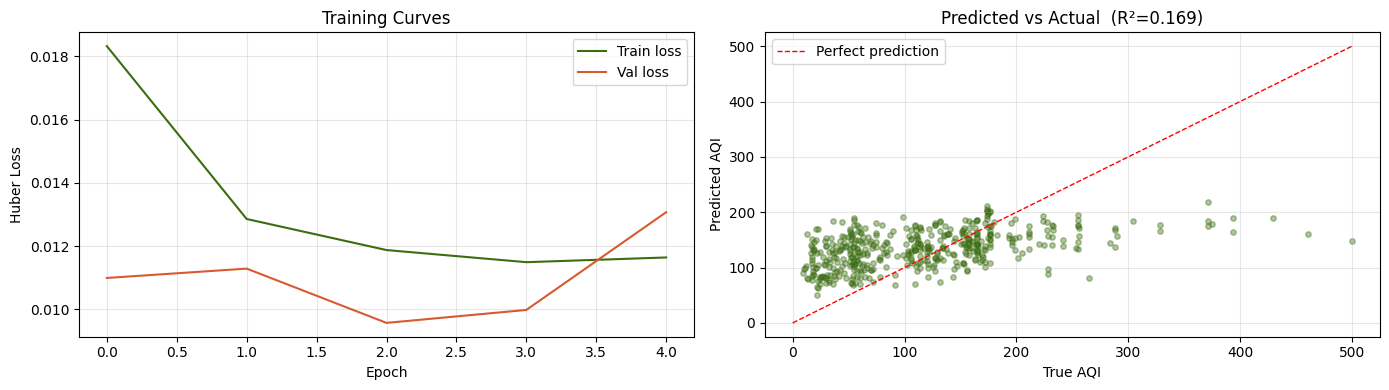

In [34]:
# Load best checkpoint
ckpt = torch.load("checkpoints/best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"  Loaded checkpoint from epoch {ckpt['epoch']}")

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, _, aqi_raw in loaders["test"]:
        preds = model(imgs.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(aqi_raw.numpy())

all_preds  = np.clip(all_preds,  0, 500)
all_labels = np.array(all_labels)

mae  = mean_absolute_error(all_labels, all_preds)
rmse = np.sqrt(np.mean((all_labels - all_preds) ** 2))
r2   = r2_score(all_labels, all_preds)

# Category accuracy
pred_cats  = [aqi_to_category(p) for p in all_preds]
true_cats  = [aqi_to_category(l) for l in all_labels]
cat_acc    = np.mean([p == t for p, t in zip(pred_cats, true_cats)]) * 100

print(f"\n  Test Set Results")
print(f"  MAE              : {mae:.2f} AQI units")
print(f"  RMSE             : {rmse:.2f} AQI units")
print(f"  R²               : {r2:.4f}")

# Plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training curves
axes[0].plot(history["train"], label="Train loss", color="#3B6D11")
axes[0].plot(history["val"],   label="Val loss",   color="#D85A30")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Huber Loss")
axes[0].set_title("Training Curves"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Predicted vs actual scatter
axes[1].scatter(all_labels, all_preds, alpha=0.4, s=15, color="#3B6D11")
lims = [0, 500]
axes[1].plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
axes[1].set_xlabel("True AQI"); axes[1].set_ylabel("Predicted AQI")
axes[1].set_title(f"Predicted vs Actual  (R²={r2:.3f})")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Extracting CNN features from all splits...


Extracting train:   0%|          | 0/33 [00:00<?, ?it/s]

Extracting val:   0%|          | 0/8 [00:00<?, ?it/s]

Extracting test:   0%|          | 0/8 [00:00<?, ?it/s]

  Train : (2112, 512)  Val : (456, 512)  Test : (457, 512)

── Random Forest ──────────────────────────────────────────────────────
Fitting 3 folds for each of 36 candidates, totalling 108 fits

  Best params : {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 3, 'n_estimators': 400}

  Test MAE              : 52.01
  Test RMSE             : 68.57
  Test R²               : 0.2499

  Top-10 CNN feature indices by importance:
     1. feature[406]  importance=0.0456
     2. feature[367]  importance=0.0436
     3. feature[ 63]  importance=0.0292
     4. feature[155]  importance=0.0216
     5. feature[301]  importance=0.0185
     6. feature[255]  importance=0.0140
     7. feature[457]  importance=0.0114
     8. feature[270]  importance=0.0103
     9. feature[505]  importance=0.0096
    10. feature[185]  importance=0.0089

── SVM (SVR) ──────────────────────────────────────────────────────────
Fitting 3 folds for each of 24 candidates, totalling 72 fits

  Best params : {'svr__C':

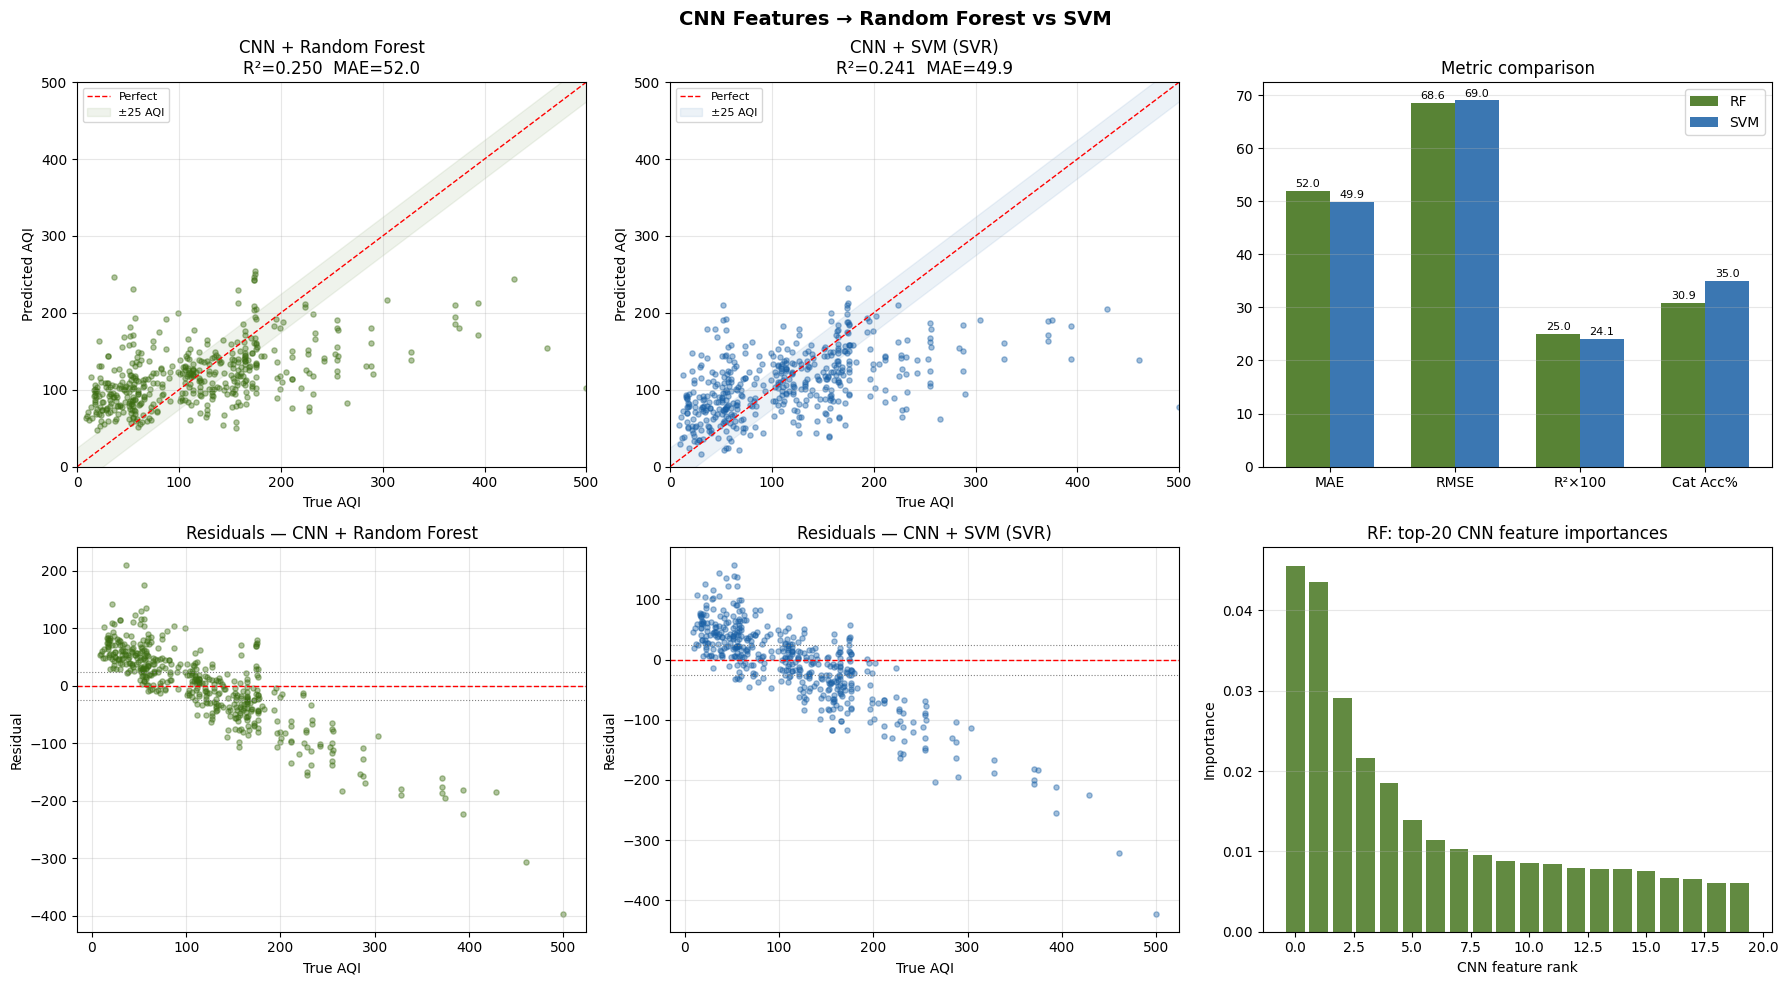


✓ Models saved to checkpoints/


In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# CNN FEATURE EXTRACTION + RANDOM FOREST & SVM
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Extract 512-d GAP features from frozen CNN
# ─────────────────────────────────────────────────────────────────────────────

class FeatureExtractor(nn.Module):
    """Wraps the trained CNN and returns GAP embeddings instead of AQI."""
    def __init__(self, cnn):
        super().__init__()
        self.features = cnn.features
        self.gap      = cnn.gap

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)   # (B, 512)
        return x


def extract_features(extractor, loader, device, split_name=""):
    """Run full DataLoader through extractor; return (N,512) array + labels."""
    extractor.eval()
    feats, labels = [], []

    with torch.no_grad():
        for imgs, _, aqi_raw in tqdm(loader, desc=f"Extracting {split_name}", leave=False):
            imgs = imgs.to(device, non_blocking=True)
            emb  = extractor(imgs).cpu().numpy()   # (B, 512)
            feats.append(emb)
            labels.append(aqi_raw.numpy())

    return np.vstack(feats), np.concatenate(labels)


# Load best CNN checkpoint before extracting
ckpt = torch.load("checkpoints/best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

extractor = FeatureExtractor(model).to(DEVICE)

print("Extracting CNN features from all splits...")
X_train, y_train = extract_features(extractor, loaders["train"], DEVICE, "train")
X_val,   y_val   = extract_features(extractor, loaders["val"],   DEVICE, "val")
X_test,  y_test  = extract_features(extractor, loaders["test"],  DEVICE, "test")

# Combine train+val for final sklearn model fitting
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

print(f"  Train : {X_train.shape}  Val : {X_val.shape}  Test : {X_test.shape}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Random Forest
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Random Forest ──────────────────────────────────────────────────────")

# Hyperparameter search on train+val with 3-fold CV
rf_param_grid = {
    "n_estimators" : [200, 400],
    "max_depth"    : [None, 20, 40],
    "max_features" : [0.2, 0.3, "sqrt"],
    "min_samples_leaf": [1, 3],
}

rf_base = RandomForestRegressor(n_jobs=-1, random_state=42)

rf_search = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_trainval, y_trainval)

rf_best = rf_search.best_estimator_
print(f"\n  Best params : {rf_search.best_params_}")

# Evaluate on held-out test set
rf_preds = np.clip(rf_best.predict(X_test), 0, 500)
rf_mae   = mean_absolute_error(y_test, rf_preds)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2    = r2_score(y_test, rf_preds)
rf_cats  = [aqi_to_category(p) for p in rf_preds]
rf_true  = [aqi_to_category(l) for l in y_test]
rf_cacc  = np.mean([p == t for p, t in zip(rf_cats, rf_true)]) * 100

print(f"\n  Test MAE              : {rf_mae:.2f}")
print(f"  Test RMSE             : {rf_rmse:.2f}")
print(f"  Test R²               : {rf_r2:.4f}")


# Feature importance — which of the 512 CNN channels matter most
rf_importances = rf_best.feature_importances_
top10_idx      = np.argsort(rf_importances)[::-1][:10]
print(f"\n  Top-10 CNN feature indices by importance:")
for rank, idx in enumerate(top10_idx, 1):
    print(f"    {rank:2d}. feature[{idx:3d}]  importance={rf_importances[idx]:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — SVM (SVR)
# ─────────────────────────────────────────────────────────────────────────────

print("\n── SVM (SVR) ──────────────────────────────────────────────────────────")

# StandardScaler is mandatory for SVR — RBF kernel is distance-based
# GridSearchCV on C and epsilon; gamma="scale" is almost always best
svm_param_grid = {
    "svr__C"      : [1, 10, 50, 100],
    "svr__epsilon": [1.0, 5.0, 10.0],    # AQI units of tolerance band
    "svr__gamma"  : ["scale", "auto"],
}

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr",    SVR(kernel="rbf", max_iter=5000)),
])

svm_search = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)
svm_search.fit(X_trainval, y_trainval)

svm_best = svm_search.best_estimator_
print(f"\n  Best params : {svm_search.best_params_}")

svm_preds = np.clip(svm_best.predict(X_test), 0, 500)
svm_mae   = mean_absolute_error(y_test, svm_preds)
svm_rmse  = np.sqrt(mean_squared_error(y_test, svm_preds))
svm_r2    = r2_score(y_test, svm_preds)
svm_cats  = [aqi_to_category(p) for p in svm_preds]
svm_cacc  = np.mean([p == t for p, t in zip(svm_cats, rf_true)]) * 100

print(f"\n  Test MAE              : {svm_mae:.2f}")
print(f"  Test RMSE             : {svm_rmse:.2f}")
print(f"  Test R²               : {svm_r2:.4f}")



# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Head-to-head comparison plots
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("CNN Features → Random Forest vs SVM", fontsize=14, fontweight="bold")

models_eval = [
    ("CNN + Random Forest", rf_preds,  "#3B6D11"),
    ("CNN + SVM (SVR)",     svm_preds, "#185FA5"),
]

for col, (name, preds, color) in enumerate(models_eval):
    r2  = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)

    # Predicted vs Actual
    ax = axes[0, col]
    ax.scatter(y_test, preds, alpha=0.4, s=14, color=color)
    ax.plot([0,500],[0,500], "r--", lw=1, label="Perfect")
    ax.fill_between([0,500],[-25,475],[25,525], alpha=0.08, color=color, label="±25 AQI")
    ax.set_xlabel("True AQI"); ax.set_ylabel("Predicted AQI")
    ax.set_title(f"{name}\nR²={r2:.3f}  MAE={mae:.1f}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(0, 500); ax.set_ylim(0, 500)

    # Residuals
    ax = axes[1, col]
    residuals = preds - y_test
    ax.scatter(y_test, residuals, alpha=0.4, s=14, color=color)
    ax.axhline(0,  color="red",  lw=1, linestyle="--")
    ax.axhline( 25, color="gray", lw=0.8, linestyle=":")
    ax.axhline(-25, color="gray", lw=0.8, linestyle=":")
    ax.set_xlabel("True AQI"); ax.set_ylabel("Residual")
    ax.set_title(f"Residuals — {name}")
    ax.grid(alpha=0.3)

# Metric bar chart (rightmost column)
metrics   = ["MAE", "RMSE", "R²×100", "Cat Acc%"]
rf_vals   = [rf_mae,  rf_rmse,  rf_r2*100,  rf_cacc]
svm_vals  = [svm_mae, svm_rmse, svm_r2*100, svm_cacc]

x   = np.arange(len(metrics))
w   = 0.35
ax  = axes[0, 2]
b1  = ax.bar(x - w/2, rf_vals,  w, label="RF",  color="#3B6D11", alpha=0.85)
b2  = ax.bar(x + w/2, svm_vals, w, label="SVM", color="#185FA5", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title("Metric comparison"); ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

# RF feature importance (bottom right)
ax = axes[1, 2]
top20     = np.argsort(rf_importances)[::-1][:20]
ax.bar(range(20), rf_importances[top20], color="#3B6D11", alpha=0.8)
ax.set_xlabel("CNN feature rank"); ax.set_ylabel("Importance")
ax.set_title("RF: top-20 CNN feature importances")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("rf_svm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Save both models
# ─────────────────────────────────────────────────────────────────────────────

import joblib
joblib.dump(rf_best,  "checkpoints/rf_on_cnn_features.pkl")
joblib.dump(svm_best, "checkpoints/svm_on_cnn_features.pkl")
print("\n✓ Models saved to checkpoints/")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — Inference helper: single image through CNN → RF or SVM
# ─────────────────────────────────────────────────────────────────────────────

def predict_with_sklearn(image_path, sk_model, model_name=""):
    """Predict AQI for one image using CNN features + sklearn model."""
    transform = get_transforms(augment=False)
    img       = Image.open(image_path).convert("RGB")
    w, h      = img.size
    crop      = img.crop((0, 0, w, int(h * 0.7)))
    tensor    = transform(crop).unsqueeze(0).to(DEVICE)

    t0 = time.perf_counter()
    with torch.no_grad():
        feat = extractor(tensor).cpu().numpy()   # (1, 512)
    aqi_raw  = float(sk_model.predict(feat)[0])
    ms       = (time.perf_counter() - t0) * 1000

    aqi      = int(np.clip(aqi_raw, 0, 500))
    category = aqi_to_category(aqi)
    print(f"  [{model_name}]  AQI: {aqi}  |  {category}  |  {ms:.1f} ms")
    return aqi, category

##  Predict AQI from Your Own Image


Enter the path to a sky image file (jpg / png).
Example:  photos/sky1.jpg  or  C:/Users/you/Downloads/sky.png



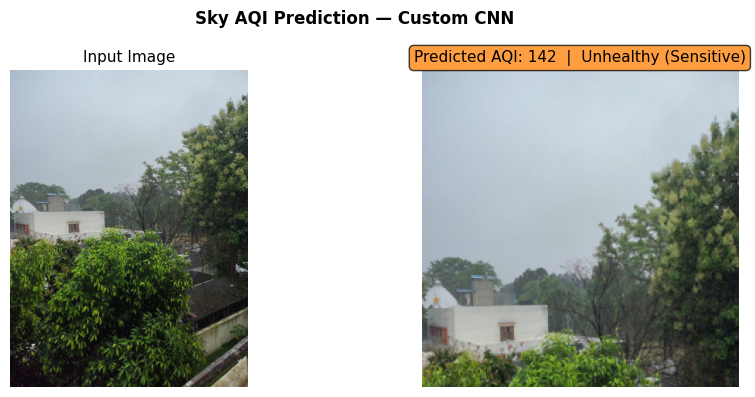

  Predicted AQI   : 142    
  Category        : Unhealthy (Sensitive)
  Inference time  : 50.0 ms


In [37]:
def predict_aqi(image_path):
    """Predict AQI for a single sky image."""
    model.eval()
    transform = get_transforms(augment=False)

    # Load and crop to sky region (top 60%)
    img      = Image.open(image_path).convert("RGB")
    w, h     = img.size
    sky_crop = img.crop((0, 0, w, int(h * 0.6)))

    # Preprocess and run through CNN
    tensor = transform(sky_crop).unsqueeze(0).to(DEVICE)
    t0     = time.time()
    with torch.no_grad():
        raw_pred = float(model(tensor).cpu())
    ms = (time.time() - t0) * 1000

    aqi      = max(0, min(500, int(raw_pred)))
    category = aqi_to_category(aqi)
    color    = next(c for t, _, c in AQI_CATEGORIES if aqi <= t)

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(np.array(img))
    axes[0].set_title("Input Image", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(np.array(sky_crop.resize((IMAGE_SIZE, IMAGE_SIZE))))
    axes[1].set_title(
        f"Predicted AQI: {aqi}  |  {category}",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor=color, alpha=0.75)
    )
    axes[1].axis("off")
    plt.suptitle("Sky AQI Prediction — Custom CNN", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Predicted AQI   : {aqi:<6} ")
    print(f"  Category        : {category:<20}")
    print(f"  Inference time  : {ms:.1f} ms")

    return {"aqi": aqi, "category": category, "inference_ms": round(ms, 1)}



print("Enter the path to a sky image file (jpg / png).")
print("Example:  photos/sky1.jpg  or  C:/Users/you/Downloads/sky.png")
print()
user_path = input("Image path: ").strip().strip('"').strip("'")

if not os.path.exists(user_path):
    print(f"\n  File not found: {user_path}")
    print("    Please check the path and run the cell again.")
else:
    result = predict_aqi(user_path)